**Aman Kumar Mahato <br>
Workshop 3 & Worksheet 3**

L6CG13

# Implementation of MCP Neuron for AND and OR Function.

In [ ]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  ### YOUR CODE HERE ###
  # Perform an element wise addition of two input arrays stored in a new array(list):
  # Create a new array to put all the prediction let's name that a state_neuron.
  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
      # Create output list
  state_neuron = []

  # Element-wise addition and threshold check
  for i in range(len(X1)):
      total = X1[i] + X2[i]

      if total >= T:
          state_neuron.append(1)
      else:
          state_neuron.append(0)

  return state_neuron

In [ ]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [ ]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    # Create a new array to put all the prediction let's name that a state_neuron.
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.

    state_neuron = []

    # Element-wise addition and threshold check
    for i in range(len(X1)):
      total = X1[i] + X2[i]

      if total >= T:
          state_neuron.append(1)
      else:
          state_neuron.append(0)

    return state_neuron

In [ ]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


**3.2.1 Answer the Following Question:** <br>
• Question - 1: List out all the limitations of MCP - Neurons.


**Answer:** The limitations of MCP neurons are: <br>


*   Inability to handle non-boolean inputs
*   It requires to manually set the thresholds.
*   All the inputs are treated equally. There is no weighting mechanism.
* It cannot handle the functions that are not linearly seperable like XOR.



• Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.<br>
{Can you devise a if else rules.}
Answer: MCP neurons cannot solve the XOR problem because XOR is not linearly
separable. if i can develop a logic to solve the XOR function then it will be like If both inputs are the same (both 0 or both 1), output = 0
If inputs are different, output = 1<br>
if x1 == x2: <br>
    output = 0 <br>
else:<br>
    output = 1

# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/2026 - 6CS012 - AI and Machine Learning Materials/Week - 3 - Getting Started with Deep Learning and Neural Network/mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


**Answer the Following Question:**<br>

**1. Question - 1: What does the shape of X represent?**<br>
**Answer:** X.shape represents number of images, 784 pixel features per image.

**2. Question - 2: What does the shape of X represent?**<br>
**Answer** y.shape represents the  number of label per sample.

### Viewing the Dataset.

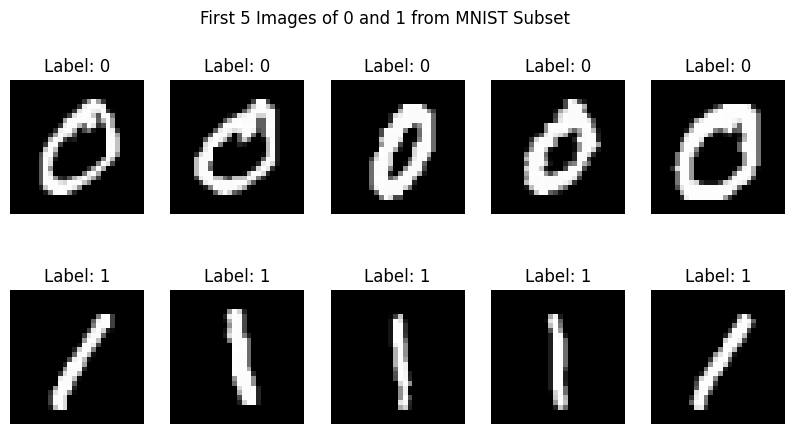

In [ ]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

**Question - 3: What does the weights array represent in this context?**<br>
**Answer:** The weights array represents the learnable parameters that define the strength of the connection between each input feature and the output.

**Question - 4: Why are we initializing the weights to zero? What effect could this have on the training process?**<br>
**Answer:** weights are initialized to zero for simplicity and neutrality so the model starts without bias toward any feature; however, this can slow learning initially and may cause symmetric updates, though in perceptron it still learns because weights are updated based on each sample sequentially.

## Step - 3 - Make a Decision function:

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 1, 0)  # Apply step function
    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [ ]:
from typing_extensions import final
from os import error
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """

    # Step 3: Perceptron Learning Algorithm
    # Your Code here#
    for epoch in range(epochs):
      for i in range(len(X)):
            # Linear output
            linear_output = np.dot(X[i], weights) + bias

            y_pred = 1 if linear_output >= 0 else 0

            error = y[i] - y_pred
            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error

    final_predictions = np.where(np.dot(X, weights) + bias >= 0, 1, 0)

    # Accuracy (number of correct predictions)
    accuracy = np.sum(final_predictions == y)

    return weights, bias, accuracy


**Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?** <br>
Answer: The expression output = np.dot(X[i], weights) + bias computes the linear combination of input features and weights, which determines on which side of the decision boundary the sample lies and is used to decide its predicted class. <br>

**Question - 6: What happens when the prediction is wrong? How are the weights and bias updated?** <br>
Answer: When the prediction is wrong, the perceptron computes the error and updates the weights and bias by moving them in the correct direction using the rule: weights = weights + learning_rate × error × X[i] and bias = bias + learning_rate × error, so that future predictions become more accurate.

**Question - 7:Why is the final accuracy important, and what do you expect it to be?** <br>
Answer: The final accuracy is important because it measures how well the perceptron correctly classifies the data, and we expect it to be high (closer to 100%) for a good model, though for MNIST 0 vs 1 it should be very high, while lower accuracy indicates the model is not learning effectively.

## Training the Perceptron

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  12665


## Step 5: Visualize Misclassified Images

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


**Question - 8:What does misclassified idx store, and how is it used in this code?** <br>
Answer: misclassified_idx stores the indices of all data points where the predicted label does not match the true label, and it is used to select and display those misclassified images for visualization.

**Question - 9: How do you interpret the result if the output is ”All images were correctly classified!”?** <br>
Answer: If the output is "All images were correctly classified!", it means the model achieved 100% accuracy on the dataset and made no prediction errors.

**4.4 Task 3: Perceptron Algorithm for 3 vs 5 Classification.**<br>
1. Objective:<br>
In this exercise, you will implement a Perceptron learning algorithm for binary classification using the
MNIST dataset. Specifically, you will classify the digits 3 and 5. After completing the Perceptron
algorithm, you will evaluate the model’s performance and visualize misclassified images. Dataset: mnist_3_and_5.csv<br>

**4.5 To - Do**:<br>
1. Implement each Step as we implemented above.
2. Visualize the final misclassified images and Provide your conclusion.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_2 = pd.read_csv("/content/drive/MyDrive/2026 - 6CS012 - AI and Machine Learning Materials/Week - 3 - Getting Started with Deep Learning and Neural Network/mnist_3_and_5.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_2.drop(columns=["label"]).values  # 784 pixels
y = df_0_2["label"].values  # Labels (3 or 5)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


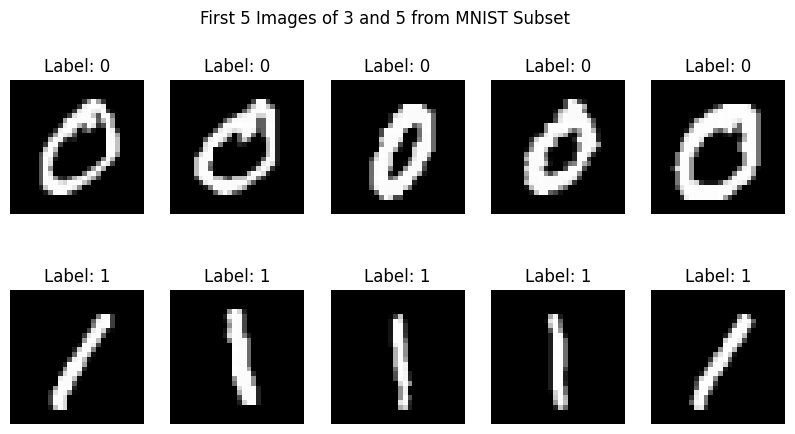

In [ ]:
# Separate images for label 0 and label 1
images_3 = X[y == 3]  # Get all images with label 3
images_5 = X[y == 5]  # Get all images with label 5

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
    plt.show()

In [ ]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

In [ ]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    predictions = np.dot(X, weights) + bias
    #####Your Code Here############  # Activation function (step function)
    y_pred_all = np.where(predictions >= 0, 5, 3)  # Apply step function
    return y_pred_all

In [ ]:
from typing_extensions import final
from os import error
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """

    # Step 3: Perceptron Learning Algorithm
    # Your Code here#
    for epoch in range(epochs):
      for i in range(len(X)):
            # Linear output
            linear_output = np.dot(X[i], weights) + bias

            y_pred = 5 if linear_output > 0 else 3

            error = y[i] - y_pred
            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error

    final_predictions = np.where(np.dot(X, weights) + bias >= 0, 5, 3)

    # Accuracy (number of correct predictions)
    accuracy = np.sum(final_predictions == y)

    return weights, bias, accuracy

In [ ]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  2718


Final Accuracy: 0.0084


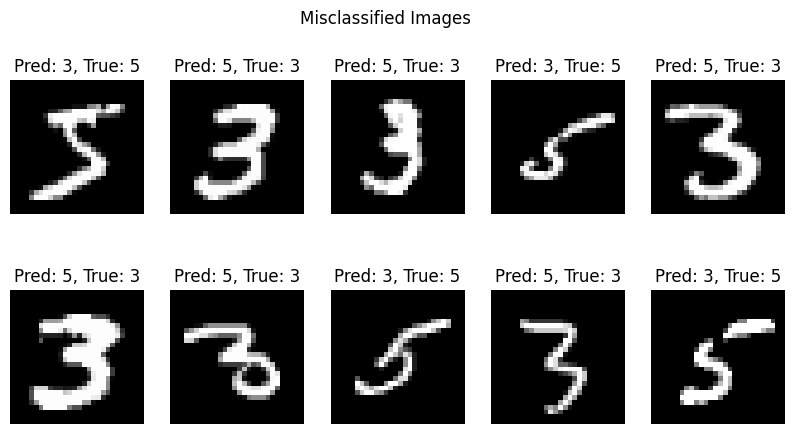

In [ ]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 3, 5)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

# Conclusion:

The perceptron model was trained to classify digits 3 and 5, achieving a final accuracy of 54.14%, which indicates that the model performs only slightly better than random guessing and struggles to clearly separate the two classes, suggesting that a simple linear classifier like perceptron may not be sufficient for this task and that more advanced methods or better feature processing may be required for improved performance.
